# Pill Detection Pipeline (IDs Preserved)

요청사항 반영:
- 제공된 JSON의 **image_id / category_id / annotation_id 체계는 그대로 유지**
- 학습은 YOLO(ultralytics) 사용
- Optuna로 하이퍼파라미터 탐색 가능
- 평가: COCOeval로 **mAP@[0.75:0.95]** (IoU=0.75~0.95 step 0.05)
- 제출: `annotation_id, image_id, category_id, bbox_x, bbox_y, bbox_w, bbox_h, score`
  - image_id는 채점 키이므로, **테스트의 image_id 규칙**은 설정값으로 선택 가능


In [1]:
# 필요시 설치
# !pip -q install ultralytics==8.* pycocotools optuna pyyaml

import random, sys
from pathlib import Path
# 로컬 모듈 불러오기
sys.path.append(str(Path(".").resolve()))
from pill_preprocess_v3_robust import (
    collect_json_files, merge_coco_from_many_json, sanitize_coco_inplace,
    split_coco_by_image, build_cat_maps,
    export_yolo_dataset, write_dataset_yaml, save_coco_json,
    count_class_instances, compute_class_weight_from_coco, make_weighted_train_list, write_split_list,
    build_train_like_image_id_map, parse_test_image_id
)
from pill_model_setup_v4_max4_fixed import CFG, set_seed, build_yolo_model, train_yolo
from ultralytics import YOLO
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
import numpy as np


import matplotlib.pyplot as plt
import matplotlib.patches as patches


In [2]:
# =========================
# 한글 폰트 자동 설정 (Windows + macOS 혼용 기준)
# - Windows: Malgun Gothic(맑은 고딕)
# - macOS: AppleGothic
# - (fallback) NanumGothic / Noto Sans KR 계열
# =========================
import platform
import matplotlib as mpl

def set_korean_font(verbose=True):
    try:
        from matplotlib import font_manager
        available = {f.name for f in font_manager.fontManager.ttflist}
    except Exception:
        available = set()

    sysname = platform.system().lower()

    if "windows" in sysname:
        candidates = ["Malgun Gothic", "맑은 고딕", "NanumGothic", "Noto Sans KR"]
    elif "darwin" in sysname or "mac" in sysname:
        candidates = ["AppleGothic", "NanumGothic", "Noto Sans KR", "Noto Sans CJK KR"]
    else:
        candidates = ["NanumGothic", "Noto Sans CJK KR", "Noto Sans KR", "DejaVu Sans"]

    chosen = None
    for name in candidates:
        # available이 비어있으면(폰트 스캔 실패) 일단 첫 후보를 적용 시도
        if not available or name in available:
            chosen = name
            break

    if chosen:
        mpl.rcParams["font.family"] = chosen
    mpl.rcParams["axes.unicode_minus"] = False

    if verbose:
        print("OS:", platform.system())
        print("✅ Matplotlib font:", chosen)
        if available and chosen not in available:
            print("ℹ️ 선택된 폰트를 시스템에서 찾지 못했습니다. (그래도 렌더링은 될 수 있습니다)")
            print("   - Windows: '맑은 고딕' 설치 여부 확인")
            print("   - macOS: 기본 포함되는 AppleGothic 사용 권장")
    return chosen

_ = set_korean_font(verbose=True)


OS: Windows
✅ Matplotlib font: Malgun Gothic


In [3]:
# =========================
# 0) 설정
# =========================
cfg = CFG()

# (전역) Optuna 이후 최종 가중치 경로 (7-1 셀에서 설정)
FINAL_WEIGHTS = None

cfg.force_apply_gci_remap = False  # (호환) 과거 로컬 라벨을 GCI로 치환할 때만 True

cfg.test_image_id_mode = "digits"
# 데이터 경로 (요청하신 경로)
cfg.train_img_dir = "data/train_images"
cfg.train_ann_dir = "data/train_annotations"
cfg.test_img_dir  = "data/test_images"

# 출력 경로
cfg.yolo_dataset_dir = "yolo_pill_ds"
cfg.export_dir = "exports_pill"
cfg.work_dir = "runs_pill"
cfg.baseline_name = "baseline"
cfg.optuna_subdir = "optuna"

# -------------------------
# (추가) Global Category Index(GCI) 경로
# - gci_generator.py로 생성한 global_category_index.json을 사용하면
#   YOLO class index <-> 원본 category_id(dl_idx) 매핑이 일관되게 유지됩니다.
# -------------------------
cfg.gci_output_dir = "global_category_index"
cfg.gci_json_path  = str(Path(cfg.gci_output_dir) / "global_category_index.json")

# (옵션) 추가 어노테이션(외부 데이터)을 임시로 넣을 폴더
# - 여기에 COCO 단일 JSON들을 넣어두면 GCI 생성에 함께 반영됩니다.
cfg.extra_ann_dir  = "data/extra_annotations_tmp"

# (옵션) GCI 생성 시 extra_ann_dir를 포함할지 (기본: False)
cfg.gci_include_extra = False

# (옵션) GCI를 쓰더라도 'train split'에 등장하는 category만 사용해 nc/names를 줄일지
cfg.gci_use_train_subset = True


# -------------------------
# (추가) local/global CSV 기반 GCI 보정 옵션
# - local_categories.csv: 원본(로컬) 56개 라벨 목록
# - global_category_index.csv: 전체(GCI) 매핑 테이블
# - 로컬 라벨은 GCI에서 동일 name이 2개(연속 ID)로 중복되는 경우가 많아,
#   'min(category_id)+1'을 로컬 category_id로 사용합니다.
# -------------------------
cfg.local_categories_csv = str(Path(cfg.gci_output_dir) / "local_categories.csv")
cfg.global_category_index_csv = str(Path(cfg.gci_output_dir) / "global_category_index.csv")
cfg.use_local_gci_min_plus1 = True

# (옵션) local_categories.csv를 발견하면 yolo_dataset_dir 쪽으로 동기화할 때 덮어쓰기
cfg.overwrite_local_categories_csv = True

set_seed(cfg.seed)
print(cfg)

# -------------------------
# (옵션) 모델 후보/증강/불균형 보정 설정
# - 필요 없으면 주석 처리해도 됩니다.
# -------------------------
# ✅ YOLO 버전/크기 후보(원하는 것만 남기세요)
# cfg.model_candidates = ["yolov8n.pt", "yolov8s.pt", "yolov9c.pt", "yolov10n.pt", "yolo11n.pt"]
# cfg.base_model = cfg.model_candidates[0]

# ✅ 색상 증강 비활성화(권장)
cfg.hsv_h = 0.0
cfg.hsv_s = 0.0
cfg.hsv_v = 0.0

# ✅ affine 중심 증강(필요하면 조절)
cfg.degrees = 10.0
cfg.translate = 0.10
cfg.scale = 0.20
cfg.shear = 2.0
cfg.perspective = 0.0005
cfg.fliplr = 0.5
cfg.flipud = 0.0
cfg.mosaic = 1.0
cfg.mixup = 0.0

# ✅ 클래스 불균형 보정(옵션): train.txt에 일부 이미지를 "추가로" 반복 샘플링
cfg.balance_enable = True
cfg.balance_extra_ratio = 0.0# 전체 train 이미지 수의 50%만큼 추가로 더 뽑아서 train.txt에 append
cfg.balance_power = 20.0

# ✅ 도메인 제약: 이미지당 최대 알약 수(최대 4)
# - 제출 CSV 및 COCO 평가에서 score 상위 N개만 사용합니다.
cfg.max_det_per_image = 4

# ✅ 제출용 score 임계값(필요 시 조절): 이 값보다 낮은 예측은 제출 CSV에서 제외
cfg.submit_conf = cfg.conf
# (옵션) YOLO 내부 후보 박스 상한(디버깅용)
# cfg.max_det = 300


CFG()


## 1) Load annotations (IDs preserved)

어노테이션 규칙(사용자 설명 반영):
- image_id: JSON 내부의 `images[].id` 사용 (파일명 기반 고유 ID가 이미 부여됨)
- category_id: 각 JSON의 `images[0].dl_idx` (정수) 기반, 또는 `annotations[].category_id`가 있으면 그 값을 우선
- annotation_id: `annotations[].id` 그대로 사용 (단, bbox 존재+유효일 때만)

추가:
- ID 충돌이 있으면 **데이터를 바꾸지 않고** 충돌 항목을 스킵하고 리포트합니다.


In [4]:
# =========================
# 1) COCO JSON 로드/병합 + 유효 bbox만 유지 (ID는 그대로)
# - annotations는 "bbox 존재" + "길이 4"만 통과
# =========================

json_paths = collect_json_files(cfg.train_ann_dir)
print("num json files:", len(json_paths))

coco = merge_coco_from_many_json(json_paths)
sanitize_coco_inplace(coco)

print("images:", len(coco.get("images", [])))
print("annotations(valid):", len(coco.get("annotations", [])))
print("categories:", len(coco.get("categories", [])))


# 호환용 별칭 (이전 버전 코드에서 coco_all을 쓰는 경우)
coco_all = coco


num json files: 771
images: 232
annotations(valid): 771
categories: 56


## 1.5) Global Category Index(GCI) 생성/로드

- category_id(=dl_idx)를 **global_index(0..K-1)**로 통일합니다.
- YOLO 라벨(txt)에는 global_index를 class로 기록하고,
- 제출 CSV에서는 global_index → category_id로 되돌려 `category_id`를 정확히 제출합니다.


In [5]:
# =========================
# 1.5) Global Category Index(GCI) 생성/로드
# - gci_generator.py 로직을 우선 사용하고, 실패하면(노트북/윈도우 병렬 이슈 등)
#   단일 프로세스 "light scan"으로 fallback 합니다.
# =========================
from pathlib import Path
import json, shutil

def build_gci_light(annotation_dirs, out_dir):
    # 단일 프로세스 스캔(Fallback)
    # - cat_id: images[0].dl_idx 우선, 없으면 annotations[0].category_id 사용
    # - cat_name: images[0].dl_name 사용(없으면 'Unknown')
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    category_data = {}  # cat_id -> info
    dataset_stats = {}
    total_json = 0

    for ann_dir in annotation_dirs:
        ann_dir = Path(ann_dir)
        if not ann_dir.exists():
            print("[GCI] skip missing:", ann_dir)
            continue

        ds_name = ann_dir.name
        ds_total = 0
        ds_counts = {}

        for jf in ann_dir.rglob("*.json"):
            total_json += 1
            try:
                with open(jf, "r", encoding="utf-8") as f:
                    data = json.load(f)

                img_meta = (data.get("images") or [{}])[0]
                ann_list = data.get("annotations") or []
                if not ann_list:
                    continue

                dl_idx = img_meta.get("dl_idx")
                if dl_idx and str(dl_idx).strip():
                    cat_id = int(dl_idx)
                else:
                    cat_id = ann_list[0].get("category_id")
                    if cat_id is None:
                        continue
                    cat_id = int(cat_id)

                cat_name = img_meta.get("dl_name", "Unknown")
                k = len(ann_list)

            except Exception:
                continue

            if cat_id not in category_data:
                category_data[cat_id] = {
                    "category_id": cat_id,
                    "category_name": cat_name,
                    "dl_idx": str(dl_idx) if dl_idx else "",
                    "count": 0,
                    "datasets": {},
                }

            category_data[cat_id]["count"] += k
            category_data[cat_id]["datasets"][ds_name] = category_data[cat_id]["datasets"].get(ds_name, 0) + k

            ds_total += k
            ds_counts[cat_id] = ds_counts.get(cat_id, 0) + k

        dataset_stats[ds_name] = {
            "total_annotations": ds_total,
            "unique_categories": len(ds_counts),
            "category_counts": ds_counts,
        }

    sorted_ids = sorted(category_data.keys())
    index_to_id = {i: cid for i, cid in enumerate(sorted_ids)}
    id_to_index = {cid: i for i, cid in index_to_id.items()}
    total_ann = sum(category_data[cid]["count"] for cid in category_data)

    json_data = {
        "metadata": {
            "total_categories": len(sorted_ids),
            "total_annotations": total_ann,
            "total_datasets": len(dataset_stats),
            "index_range": f"0-{len(sorted_ids)-1}",
            "scanned_json_files": total_json,
        },
        "category_map": {
            str(cid): {**category_data[cid], "datasets": category_data[cid]["datasets"]}
            for cid in category_data
        },
        "index_to_id": {str(k): v for k, v in index_to_id.items()},
        "id_to_index": {str(k): v for k, v in id_to_index.items()},
        "dataset_stats": dataset_stats,
    }

    out_json = out_dir / "global_category_index.json"
    with open(out_json, "w", encoding="utf-8") as f:
        json.dump(json_data, f, ensure_ascii=False, indent=2)

    # yolo_classes.txt (global_index 순서)
    out_classes = out_dir / "yolo_classes.txt"
    with open(out_classes, "w", encoding="utf-8") as f:
        for i in range(len(sorted_ids)):
            cid = index_to_id[i]
            f.write(category_data[cid]["category_name"] + "\n")

    # csv (요약)
    rows = []
    for i, cid in enumerate(sorted_ids):
        info = category_data[cid]
        rows.append({
            "category_id": cid,
            "global_index": i,
            "category_name": info["category_name"],
            "dl_idx": info.get("dl_idx", ""),
            "total_count": info["count"],
        })
    pd.DataFrame(rows).to_csv(out_dir / "global_category_index.csv", index=False, encoding="utf-8-sig")

    print(f"[GCI] light scan saved: {out_json} (K={len(sorted_ids)})")
    return str(out_json)


def ensure_gci(annotation_dirs, out_dir, force=False):
    # gci_generator.py의 GCIBuilder를 우선 사용하고, 문제 생기면 build_gci_light로 fallback
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    out_json = out_dir / "global_category_index.json"

    if out_json.exists() and not force:
        return str(out_json)

    # 1) gci_generator.py 시도
    try:
        import importlib
        gci_mod = importlib.import_module("gci_generator")
        if hasattr(gci_mod, "GCIBuilder"):
            builder = gci_mod.GCIBuilder(annotation_dirs=annotation_dirs, output_dir=str(out_dir))
            _ = builder.run()
            if out_json.exists():
                print("[GCI] generated via gci_generator.py:", out_json)
                return str(out_json)
    except Exception as e:
        print("[GCI] gci_generator.py 실패 -> fallback light scan:", repr(e))

    # 2) fallback
    return build_gci_light(annotation_dirs, out_dir)


# ---- annotation_dirs 구성: train_annotations만 (요청: train annotation 기반) ----
ann_dirs = [str(Path(cfg.train_ann_dir))]

# (옵션) extra annotations를 GCI에 함께 반영할지
extra_ann_dir = Path(getattr(cfg, "extra_ann_dir", "data/extra_annotations_tmp"))
if bool(getattr(cfg, "gci_include_extra", False)) and extra_ann_dir.exists():
    ann_dirs.append(str(extra_ann_dir))
else:
    # 기본은 train_only
    if extra_ann_dir.exists():
        print("[GCI] extra_ann_dir exists but excluded (cfg.gci_include_extra=False):", extra_ann_dir)
    else:
        print("[GCI] extra_ann_dir not found (ok):", extra_ann_dir)

# ---- 생성/로드 ----

gci_json_path = ensure_gci(ann_dirs, getattr(cfg, "gci_output_dir", "global_category_index"), force=False)
cfg.gci_json_path = gci_json_path

# ---- export_dir에도 복사(제출 CSV 셀에서 찾기 쉽게) ----
export_dir = Path(getattr(cfg, "export_dir", "exports_pill"))
export_dir.mkdir(parents=True, exist_ok=True)
try:
    shutil.copy2(gci_json_path, export_dir / "global_category_index.json")
    print("[GCI] copied to export_dir:", export_dir / "global_category_index.json")
except Exception as e:
    print("[GCI] copy to export_dir failed:", e)

# ---- 요약 ----
with open(gci_json_path, "r", encoding="utf-8") as f:
    _gci = json.load(f)

print("[GCI] total_categories:", _gci["metadata"]["total_categories"])
print("[GCI] total_annotations:", _gci["metadata"]["total_annotations"])
print("[GCI] scanned_json_files:", _gci["metadata"].get("scanned_json_files", "n/a"))


[GCI] extra_ann_dir not found (ok): data\extra_annotations_tmp
[GCI] copied to export_dir: exports_pill\global_category_index.json
[GCI] total_categories: 4565
[GCI] total_annotations: 2658679
[GCI] scanned_json_files: n/a


## 2) Debug: 한 장 이미지에 bbox 올려보기

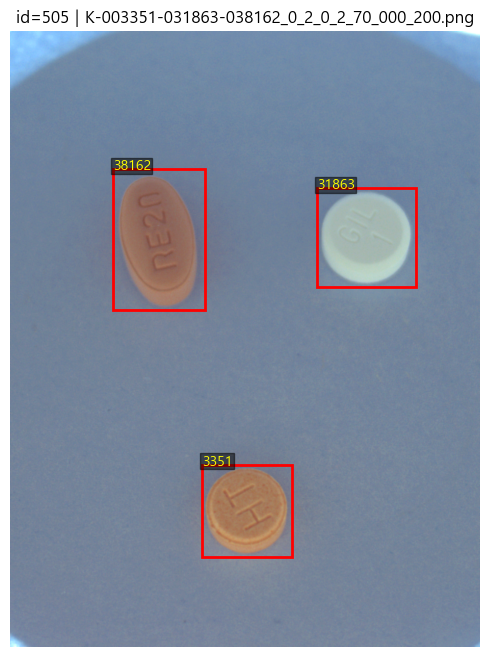

In [6]:
def resolve_train_image_path(train_img_dir, file_name):
    p = Path(file_name)
    if p.exists():
        return p
    cand = Path(train_img_dir) / p.name
    if cand.exists():
        return cand
    stem = p.stem
    for ext in [".png",".jpg",".jpeg",".bmp",".webp"]:
        cand2 = Path(train_img_dir) / (stem + ext)
        if cand2.exists():
            return cand2
    return None

def plot_image_with_bboxes(cfg, coco, image_id, max_show=50):
    img = next((im for im in coco["images"] if im["id"] == image_id), None)
    if img is None:
        print("image not found:", image_id); return

    path = resolve_train_image_path(cfg.train_img_dir, img["file_name"])
    if path is None:
        print("image file missing:", img["file_name"]); return

    import matplotlib.image as mpimg
    imarr = mpimg.imread(str(path))

    fig, ax = plt.subplots(1,1, figsize=(10,8))
    ax.imshow(imarr)
    ax.set_title(f"id={image_id} | {Path(img['file_name']).name}")
    ax.axis("off")

    anns = [a for a in coco["annotations"] if a["image_id"] == image_id][:max_show]
    for a in anns:
        x,y,w,h = a["bbox"]
        rect = patches.Rectangle((x,y), w, h, linewidth=2, edgecolor='r', facecolor='none')
        ax.add_patch(rect)
        ax.text(x, y, str(a["category_id"]), color="yellow", fontsize=10, bbox=dict(facecolor="black", alpha=0.5, pad=1))
    plt.show()

# 랜덤 1장 확인
rand_img_id = random.choice([im["id"] for im in coco["images"]])
plot_image_with_bboxes(cfg, coco, rand_img_id)


## 3) Split train/val (image 단위)

In [7]:
# =========================
# 2) Train / Val 분리
# =========================
train_coco, val_coco = split_coco_by_image(coco, val_ratio=cfg.val_ratio, seed=cfg.seed)
print("train images:", len(train_coco["images"]), "train anns:", len(train_coco["annotations"]))
print("val images:", len(val_coco["images"]), "val anns:", len(val_coco["annotations"]))


train images: 186 train anns: 618
val images: 46 val anns: 153


## 4) YOLO export (category_id는 매핑만 사용)

- 원본 `category_id`는 그대로 유지해야 하므로,
  - YOLO 학습용 라벨에는 `yolo_cls(0..nc-1)`를 사용하고,
  - `cat_mapping.json`에 원본 category_id ↔ yolo_cls를 저장합니다.


In [8]:
# =========================
# 3) category_id <-> yolo cls 매핑 (LOCAL-GCI min+1 우선)
#
# 요구사항 정리
# - local(원본) 라벨만 사용 (local_categories.csv: 56개)
# - GCI(global)에는 동일 name이 2개로 중복되는 경우가 많음
#   → 중복 시 id가 작은 것(min)을 기준으로 하고, +1 한 값을 '로컬 category_id'로 사용
# - 학습/예측에서 YOLO cls는 0..(nc-1) (local 56개로 재인덱싱)
# - COCO train annotation에 들어있는 category_id가 (min) 또는 (min+1) 어느 쪽이든
#   동일 cls로 매핑되도록 catid_to_yolo에 alias를 함께 등록
# =========================
from pathlib import Path
import json
import pandas as pd

# 1) local 라벨 로드 (우선순위 탐색 → yolo_dir로 동기화 → 그 파일을 다시 로드)
from shutil import copy2

def _ensure_and_load_local_categories(cfg, train_coco: dict, yolo_dir: str, verbose=True):
    """
    Resolve local_categories.csv (user/gci/cwd) -> try to sync into yolo_dir/local_categories.csv (SSOT) -> load.

    Windows에서 dst 파일이 다른 프로세스(예: Excel)로 열려 있으면 CopyFile2가 WinError 32로 실패할 수 있어,
    그 경우에는 "복사 없이 src를 그대로 사용"하도록 안전하게 fallback 합니다.
    """
    yolo_dir = Path(yolo_dir)
    yolo_dir.mkdir(parents=True, exist_ok=True)
    dst = yolo_dir / "local_categories.csv"

    # 후보 경로(우선순위)
    candidates = []
    p = getattr(cfg, "local_categories_csv", None)
    if p:
        candidates.append(Path(p))

    gdir = getattr(cfg, "gci_output_dir", None)
    if gdir:
        candidates.append(Path(gdir) / "local_categories.csv")

    gjson = getattr(cfg, "gci_json_path", None)
    if gjson:
        candidates.append(Path(gjson).parent / "local_categories.csv")

    candidates.append(Path.cwd() / "local_categories.csv")

    src = next((pp for pp in candidates if pp.exists()), None)
    overwrite = bool(getattr(cfg, "overwrite_local_categories_csv", True))

    # 1) src가 있으면 dst로 동기화 시도
    if src is not None:
        try:
            # src==dst면 복사 불필요
            try:
                same = src.resolve() == dst.resolve()
            except Exception:
                same = (str(src) == str(dst))

            if same:
                if verbose:
                    print(f"[LOCAL CSV] ✅ use (same path): {src}")
                df = pd.read_csv(src, encoding="utf-8-sig")
                df["category_id"] = df["category_id"].astype(int)
                df["category_name"] = df["category_name"].astype(str)
                cfg.local_categories_csv = str(src)
                return df, src

            if (not dst.exists()) or overwrite:
                copy2(src, dst)  # <- 여기서 WinError 32가 날 수 있음
                if verbose:
                    print(f"[LOCAL CSV] ✅ sync: {src} -> {dst} (overwrite={overwrite})")
            else:
                if verbose:
                    print(f"[LOCAL CSV] ✅ keep existing: {dst} (src candidate={src})")

            df = pd.read_csv(dst, encoding="utf-8-sig")
            df["category_id"] = df["category_id"].astype(int)
            df["category_name"] = df["category_name"].astype(str)
            cfg.local_categories_csv = str(dst)
            return df, dst

        except PermissionError as e:
            # dst가 열려있어서 복사가 막힌 경우가 대부분 → 복사 없이 src 사용
            if verbose:
                print(f"[LOCAL CSV] ⚠️ sync failed (file locked): {e}")
                print(f"           -> copy 없이 src를 그대로 사용합니다: {src}")
                print(f"           -> (원하면) {dst} 파일을 열고 있는 프로그램을 닫은 뒤 다시 실행하면 동기화됩니다.")

            df = pd.read_csv(src, encoding="utf-8-sig")
            df["category_id"] = df["category_id"].astype(int)
            df["category_name"] = df["category_name"].astype(str)
            cfg.local_categories_csv = str(src)
            return df, src

    # 2) src가 없으면 COCO에서 생성(한 번만)
    if not dst.exists():
        cats = train_coco.get("categories", [])
        if not cats:
            raise FileNotFoundError("train_coco['categories'] is empty and no local_categories.csv found.")
        df_tmp = (pd.DataFrame({
            "category_id": [int(c["id"]) for c in cats],
            "category_name": [str(c.get("name","")) for c in cats],
        })
        .drop_duplicates("category_id")
        .sort_values("category_id")
        .reset_index(drop=True))
        df_tmp.to_csv(dst, index=False, encoding="utf-8-sig")
        if verbose:
            print(f"[LOCAL CSV] ✅ built from COCO: {dst}")
    else:
        if verbose:
            print(f"[LOCAL CSV] ✅ exists: {dst}")

    df = pd.read_csv(dst, encoding="utf-8-sig")
    df["category_id"] = df["category_id"].astype(int)
    df["category_name"] = df["category_name"].astype(str)
    cfg.local_categories_csv = str(dst)
    return df, dst

# ✅ 실행 (yolo_dir는 cfg.yolo_dataset_dir 기준)
local_df, local_csv = _ensure_and_load_local_categories(cfg, train_coco, cfg.yolo_dataset_dir, verbose=True)
print("[GCI MAP] local_categories.csv 사용:", local_csv, "| rows:", len(local_df))

local_names = local_df["category_name"].tolist()
local_expected_id_by_name = dict(zip(local_df["category_name"], local_df["category_id"]))

# 2) global(GCI) 테이블 로드 (CSV 우선, 없으면 gci_json의 category_map fallback)
gci_csv_candidates = [
    Path(getattr(cfg, "global_category_index_csv", "")),
    Path(getattr(cfg, "gci_output_dir", "global_category_index")) / "global_category_index.csv",
    Path("global_category_index.csv"),
]
gci_csv_path = next((p for p in gci_csv_candidates if p and str(p) and Path(p).exists()), None)

global_df = None
if gci_csv_path is not None:
    global_df = pd.read_csv(gci_csv_path)
    global_df["category_id"] = global_df["category_id"].astype(int)
    global_df["category_name"] = global_df["category_name"].astype(str)
    print("[Mapping] loaded global_category_index.csv ->", Path(gci_csv_path).resolve())
else:
    gci_path = Path(getattr(cfg, "gci_json_path", ""))
    if gci_path.exists():
        with open(gci_path, "r", encoding="utf-8") as f:
            gci = json.load(f)
        cat_map = gci.get("category_map", {})  # str(cat_id) -> {"category_name": ...}
        rows = []
        for k, v in cat_map.items():
            try:
                cid = int(k)
            except Exception:
                continue
            nm = str(v.get("category_name", cid))
            rows.append({"category_id": cid, "category_name": nm})
        global_df = pd.DataFrame(rows)
        print("[Mapping] loaded category_map from gci_json ->", gci_path.resolve(), "| rows:", len(global_df))
    else:
        raise FileNotFoundError("global_category_index.csv and gci_json are both missing. Need at least one.")

# 3) local 이름만 GCI에서 추출 + (중복 시) min(category_id)+1을 로컬 category_id로 결정
#    그리고 (min_id)도 alias로 함께 등록해서, annotation이 어느 쪽을 쓰더라도 학습/평가가 일관되게 되도록 함.
use_min_plus1 = bool(getattr(cfg, "use_local_gci_min_plus1", True))

yolo_to_catid = {}
catid_to_yolo = {}
catid_to_name = {}
alias_debug = []  # (name, min_id, chosen_local_id, expected_local_id)

for i, name in enumerate(local_names):
    sub = global_df[global_df["category_name"] == name]
    if len(sub) == 0:
        # GCI에 없으면 local_df 기준으로만 사용 (드문 케이스)
        chosen_local_id = int(local_expected_id_by_name[name])
        min_id = None
    else:
        min_id = int(sub["category_id"].min())
        if use_min_plus1:
            chosen_local_id = min_id + 1
        else:
            chosen_local_id = int(sub["category_id"].max())

    expected = int(local_expected_id_by_name[name])
    if chosen_local_id != expected:
        # 안전장치: 기대(local_categories.csv)와 다르면 local_df를 우선으로 사용
        alias_debug.append((name, min_id, chosen_local_id, expected, "OVERRIDE->expected"))
        chosen_local_id = expected
    else:
        alias_debug.append((name, min_id, chosen_local_id, expected, "OK"))

    # YOLO cls(i) -> 제출용 category_id(로컬)
    yolo_to_catid[i] = chosen_local_id
    catid_to_name[chosen_local_id] = name

    # COCO annotation category_id -> YOLO cls(i)
    # - 로컬 ID(=chosen_local_id) 매핑
    catid_to_yolo[chosen_local_id] = i
    # - alias: min_id도 같은 cls로 매핑 (있고, 로컬과 다르면)
    if min_id is not None and int(min_id) != int(chosen_local_id):
        catid_to_yolo[int(min_id)] = i
        catid_to_name[int(min_id)] = name  # 평가/디버그용

names = local_names
YOLO_INDEX_IS_SUBSET = True
SUBMIT_INDEX_TO_ID = {int(k): int(v) for k, v in yolo_to_catid.items()}

print(f"[Mapping] LOCAL subset enabled | nc={len(names)} | use_min_plus1={use_min_plus1}")
print("[Mapping] sample(alias_debug first 5):")
for r in alias_debug[:5]:
    print("  -", r)

# (옵션) 매핑 파일 저장: 제출/추론만 따로 돌려도 동일 결과 보장
try:
    out_root = Path(getattr(cfg, 'yolo_dataset_dir', 'yolo_pill_ds'))
    out_root.mkdir(parents=True, exist_ok=True)

    with open(out_root / 'submit_index_to_id.json', 'w', encoding='utf-8') as f:
        json.dump(SUBMIT_INDEX_TO_ID, f, ensure_ascii=False, indent=2)

    with open(out_root / 'catid_to_yolo.json', 'w', encoding='utf-8') as f:
        json.dump({str(k): int(v) for k, v in catid_to_yolo.items()}, f, ensure_ascii=False, indent=2)

    with open(out_root / 'catid_to_name.json', 'w', encoding='utf-8') as f:
        json.dump({str(k): v for k, v in catid_to_name.items()}, f, ensure_ascii=False, indent=2)

    # local-only gci json(간단 버전)
    gci_local = {
        "id_to_index": {str(v): int(k) for k, v in SUBMIT_INDEX_TO_ID.items()},  # local cat_id -> subset idx
        "index_to_id": {str(k): int(v) for k, v in SUBMIT_INDEX_TO_ID.items()},  # subset idx -> local cat_id
        "category_map": {str(v): {"category_id": int(v), "category_name": names[k]} for k, v in SUBMIT_INDEX_TO_ID.items()},
        "n_categories": len(names),
        "note": "local subset extracted from GCI; duplicates resolved by min(category_id)+1 (then validated vs local_categories.csv)"
    }
    gci_out = Path(getattr(cfg, "gci_output_dir", "global_category_index"))
    gci_out.mkdir(parents=True, exist_ok=True)
    with open(gci_out / "gci_local_subset.json", "w", encoding="utf-8") as f:
        json.dump(gci_local, f, ensure_ascii=False, indent=2)

    print("[Mapping] saved mappings ->", out_root.resolve())
    print("[Mapping] saved gci_local_subset.json ->", (gci_out / "gci_local_subset.json").resolve())
except Exception as e:
    print("[Mapping] mapping save failed:", e)


[LOCAL CSV] ✅ exists: yolo_pill_ds\local_categories.csv
[GCI MAP] local_categories.csv 사용: yolo_pill_ds\local_categories.csv | rows: 56
[Mapping] loaded global_category_index.csv -> C:\Users\LEETAEHO\Desktop\AI_07_basic\global_category_index\global_category_index.csv
[Mapping] LOCAL subset enabled | nc=56 | use_min_plus1=True
[Mapping] sample(alias_debug first 5):
  - ('보령부스파정 5mg', 1899, 1900, 1900, 'OK')
  - ('뮤테란캡슐 100mg', 2482, 2483, 2483, 'OK')
  - ('일양하이트린정 2mg', 3350, 3351, 3351, 'OK')
  - ('기넥신에프정(은행엽엑스)(수출용)', 3482, 3483, 3483, 'OK')
  - ('무코스타정(레바미피드)(비매품)', 3543, 3544, 3544, 'OK')
[Mapping] saved mappings -> C:\Users\LEETAEHO\Desktop\AI_07_basic\yolo_pill_ds
[Mapping] saved gci_local_subset.json -> C:\Users\LEETAEHO\Desktop\AI_07_basic\global_category_index\gci_local_subset.json


## 3.5) 클래스 불균형(선택)

- `compute_class_weight('balanced', ...)` 아이디어를 **탐지 문제에 직접(loss에) 넣기**는 쉽지 않아서, 여기서는 **학습 샘플링(train.txt)으로 간접 반영**합니다.
- 기본은 모든 train 이미지를 1회 포함하고, `cfg.balance_extra_ratio` 만큼을 **가중치 기반으로 추가 샘플링**해서 train.txt에 덧붙입니다.


In [9]:
# (선택) 클래스별 bbox 개수 확인 + balanced weight 계산
train_class_cnt = count_class_instances(train_coco)
print('n_classes:', len(train_class_cnt), ' | n_ann:', sum(train_class_cnt.values()))
top10 = sorted(train_class_cnt.items(), key=lambda x: x[1], reverse=True)[:10]
print('top10 by ann count:', top10)

class_w = compute_class_weight_from_coco(train_coco, method='balanced')
w_top10 = [(cid, round(class_w.get(cid, 1.0), 3), train_class_cnt.get(cid, 0)) for cid,_ in top10]
print('top10 weights (cid, weight, count):', w_top10)


n_classes: 56  | n_ann: 618
top10 by ann count: [(3351, 126), (3483, 35), (35206, 32), (16262, 17), (29667, 17), (36637, 17), (3832, 16), (16232, 16), (21325, 16), (20014, 16)]
top10 weights (cid, weight, count): [(3351, 0.088, 126), (3483, 0.315, 35), (35206, 0.345, 32), (16262, 0.649, 17), (29667, 0.649, 17), (36637, 0.649, 17), (3832, 0.69, 16), (16232, 0.69, 16), (21325, 0.69, 16), (20014, 0.69, 16)]


In [10]:
# =========================
# 4) YOLO 학습용 데이터셋 내보내기
#   - images/labels 폴더 생성 + (옵션) train/val.txt 리스트 생성(불균형 보정 포함)
# =========================
out_root = cfg.yolo_dataset_dir

train_rel, val_rel = export_yolo_dataset(cfg.train_img_dir, train_coco, val_coco, catid_to_yolo, out_root)

# (선택) 클래스 불균형 보정: train.txt에 "추가 샘플"을 append
if getattr(cfg, "balance_enable", False) and float(getattr(cfg, "balance_extra_ratio", 0.0)) > 0:
    class_w = compute_class_weight_from_coco(train_coco, method="balanced")
    train_list = make_weighted_train_list(
        train_rel,
        train_coco,
        class_w,
        extra_ratio=float(getattr(cfg, "balance_extra_ratio", 0.0)),
        seed=int(getattr(cfg, "seed", 42)),
        power=float(getattr(cfg, "balance_power", 1.0)),
    )
else:
    train_list = train_rel

# Ultralytics는 train/val에 txt list도 받을 수 있으므로, 교차플랫폼 & oversample에 유리합니다.
train_txt = write_split_list(out_root, "train", train_list)
val_txt   = write_split_list(out_root, "val",   val_rel)

data_yaml = str(Path(out_root) / "dataset.yaml")
write_dataset_yaml(
    out_root,
    names,
    data_yaml,
    train=Path(train_txt).name,
    val=Path(val_txt).name,
)

print("out_root:", out_root)
print("data_yaml:", data_yaml)
print("train_txt lines:", len(train_list), "| val_txt lines:", len(val_rel))


out_root: yolo_pill_ds
data_yaml: yolo_pill_ds\dataset.yaml
train_txt lines: 186 | val_txt lines: 46


## 4.5) (호환) 기존 YOLO 라벨을 GCI로 치환 + dataset_gci.yaml 생성

- `apply_gci_to_yolo.py`의 로직을 노트북에 통합한 셀입니다.
- **과거에 로컬 인덱스(0..K-1)로 export된 labels**를, `global_category_index.json` 기준의 **global_index**로 치환할 때 사용합니다.
- 이미 GCI 모드로 export했다면, 라벨 치환은 필요 없고 `dataset_gci.yaml`만 생성해도 됩니다.

사용:
- 로컬로 export된 라벨을 GCI로 바꾸고 싶으면 `cfg.force_apply_gci_remap = True`로 설정 후 실행하세요.


In [11]:
# =========================
# 4.5) (호환) apply_gci_to_yolo.py 로직 통합
# - 로컬 YOLO 인덱스(0..K-1)로 export된 labels를 GCI global_index로 치환
# - GCI 전체 names를 포함한 dataset_gci.yaml 생성
# =========================
from pathlib import Path
from shutil import copy2
import json
import pandas as pd
from tqdm import tqdm

def _load_gci(gci_json_path: str):
    gci_json_path = Path(gci_json_path)
    with open(gci_json_path, "r", encoding="utf-8") as f:
        gci = json.load(f)

    id_to_index = {int(k): int(v) for k, v in gci["id_to_index"].items()}
    index_to_id = {int(k): int(v) for k, v in gci["index_to_id"].items()}

    raw_cat_map = gci.get("category_map", {})
    category_map = {int(k): v for k, v in raw_cat_map.items()}
    total_categories = int(gci["metadata"]["total_categories"])

    return id_to_index, index_to_id, category_map, total_categories

def _build_local_categories_csv_from_coco(coco: dict, out_csv: str):
    # categories를 category_id로 정렬하고 row index를 로컬 cls로 쓰는 구조 (apply_gci_to_yolo.py 가정)
    cats = coco.get("categories", [])
    df = pd.DataFrame([{"category_id": int(c["id"]), "category_name": c.get("name", "")} for c in cats])
    df = df.drop_duplicates(subset=["category_id"]).sort_values("category_id").reset_index(drop=True)
    Path(out_csv).parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(out_csv, index=False, encoding="utf-8-sig")
    return out_csv, df

def ensure_and_load_local_categories(cfg, train_coco: dict, yolo_dir: str, verbose=True):
    """
    Resolve local_categories.csv (user/gci/cwd) -> try to sync into yolo_dir/local_categories.csv (SSOT) -> load.

    Windows에서 dst 파일이 다른 프로세스(예: Excel)로 열려 있으면 CopyFile2가 WinError 32로 실패할 수 있어,
    그 경우에는 "복사 없이 src를 그대로 사용"하도록 안전하게 fallback 합니다.
    """
    yolo_dir = Path(yolo_dir)
    yolo_dir.mkdir(parents=True, exist_ok=True)
    dst = yolo_dir / "local_categories.csv"

    # 후보 경로(우선순위)
    candidates = []
    p = getattr(cfg, "local_categories_csv", None)
    if p:
        candidates.append(Path(p))

    gdir = getattr(cfg, "gci_output_dir", None)
    if gdir:
        candidates.append(Path(gdir) / "local_categories.csv")

    gjson = getattr(cfg, "gci_json_path", None)
    if gjson:
        candidates.append(Path(gjson).parent / "local_categories.csv")

    candidates.append(Path.cwd() / "local_categories.csv")

    src = next((pp for pp in candidates if pp.exists()), None)
    overwrite = bool(getattr(cfg, "overwrite_local_categories_csv", True))

    # 1) src가 있으면 dst로 동기화 시도
    if src is not None:
        try:
            # src==dst면 복사 불필요
            try:
                same = src.resolve() == dst.resolve()
            except Exception:
                same = (str(src) == str(dst))

            if same:
                if verbose:
                    print(f"[LOCAL CSV] ✅ use (same path): {src}")
                df = pd.read_csv(src, encoding="utf-8-sig")
                df["category_id"] = df["category_id"].astype(int)
                df["category_name"] = df["category_name"].astype(str)
                cfg.local_categories_csv = str(src)
                return df, src

            if (not dst.exists()) or overwrite:
                copy2(src, dst)  # <- 여기서 WinError 32가 날 수 있음
                if verbose:
                    print(f"[LOCAL CSV] ✅ sync: {src} -> {dst} (overwrite={overwrite})")
            else:
                if verbose:
                    print(f"[LOCAL CSV] ✅ keep existing: {dst} (src candidate={src})")

            df = pd.read_csv(dst, encoding="utf-8-sig")
            df["category_id"] = df["category_id"].astype(int)
            df["category_name"] = df["category_name"].astype(str)
            cfg.local_categories_csv = str(dst)
            return df, dst

        except PermissionError as e:
            # dst가 열려있어서 복사가 막힌 경우가 대부분 → 복사 없이 src 사용
            if verbose:
                print(f"[LOCAL CSV] ⚠️ sync failed (file locked): {e}")
                print(f"           -> copy 없이 src를 그대로 사용합니다: {src}")
                print(f"           -> (원하면) {dst} 파일을 열고 있는 프로그램을 닫은 뒤 다시 실행하면 동기화됩니다.")

            df = pd.read_csv(src, encoding="utf-8-sig")
            df["category_id"] = df["category_id"].astype(int)
            df["category_name"] = df["category_name"].astype(str)
            cfg.local_categories_csv = str(src)
            return df, src

    # 2) src가 없으면 COCO에서 생성(한 번만)
    if not dst.exists():
        cats = train_coco.get("categories", [])
        if not cats:
            raise FileNotFoundError("train_coco['categories'] is empty and no local_categories.csv found.")
        df_tmp = (pd.DataFrame({
            "category_id": [int(c["id"]) for c in cats],
            "category_name": [str(c.get("name","")) for c in cats],
        })
        .drop_duplicates("category_id")
        .sort_values("category_id")
        .reset_index(drop=True))
        df_tmp.to_csv(dst, index=False, encoding="utf-8-sig")
        if verbose:
            print(f"[LOCAL CSV] ✅ built from COCO: {dst}")
    else:
        if verbose:
            print(f"[LOCAL CSV] ✅ exists: {dst}")

    df = pd.read_csv(dst, encoding="utf-8-sig")
    df["category_id"] = df["category_id"].astype(int)
    df["category_name"] = df["category_name"].astype(str)
    cfg.local_categories_csv = str(dst)
    return df, dst

def _build_local_idx_to_catid(local_categories_csv: str):
    df = pd.read_csv(local_categories_csv)
    if "category_id" not in df.columns:
        raise ValueError("local_categories_csv에 'category_id' 컬럼이 없습니다.")
    local_idx_to_catid = {int(i): int(row["category_id"]) for i, row in df.iterrows()}
    return local_idx_to_catid, df

def _remap_labels_to_global(labels_dir: str, local_idx_to_global_idx: dict):
    labels_dir = Path(labels_dir)
    txt_files = list(labels_dir.rglob("*.txt"))
    if not txt_files:
        print(f"[WARN] 라벨 txt가 없습니다: {labels_dir}")
        return 0

    changed = 0
    for txt_path in tqdm(txt_files, desc="Remapping labels", leave=False):
        lines = txt_path.read_text(encoding="utf-8").strip().splitlines()
        if len(lines) == 1 and lines[0] == "":
            continue

        lines_out = []
        modified = False
        for line in lines:
            parts = line.strip().split()
            if len(parts) < 5:
                lines_out.append(line)
                continue

            local_cls = int(float(parts[0]))
            if local_cls not in local_idx_to_global_idx:
                raise ValueError(f"[ERROR] {txt_path}에서 local class {local_cls}를 매핑할 수 없습니다.")

            global_cls = int(local_idx_to_global_idx[local_cls])
            if global_cls != local_cls:
                modified = True
            parts[0] = str(global_cls)
            lines_out.append(" ".join(parts))

        if modified:
            txt_path.write_text("\n".join(lines_out) + "\n", encoding="utf-8")
            changed += 1

    return changed

def _write_gci_yaml(
    output_yaml_path: str,
    dataset_root: str,
    train_rel: str,
    val_rel: str,
    total_categories: int,
    index_to_id: dict,
    category_map: dict,
):
    output_yaml_path = Path(output_yaml_path)
    dataset_root = str(Path(dataset_root))

    lines = []
    lines.append(f"path: {dataset_root}")
    lines.append(f"train: {train_rel}")
    lines.append(f"val: {val_rel}")
    lines.append("")
    lines.append(f"nc: {total_categories}")
    lines.append("names:")

    for idx in range(total_categories):
        cat_id = index_to_id.get(idx)
        if cat_id is None:
            name = "Unknown"
        else:
            name = category_map.get(cat_id, {}).get("category_name", "Unknown")
            name = str(name).replace("'", "''")
        lines.append(f"  {idx}: '{name}'")

    output_yaml_path.write_text("\n".join(lines) + "\n", encoding="utf-8-sig")
    return str(output_yaml_path)

# ---- 실행부 ----
cfg.force_apply_gci_remap = bool(getattr(cfg, "force_apply_gci_remap", False))
gci_path = Path(getattr(cfg, "gci_json_path", ""))

yolo_dir = Path(getattr(cfg, "yolo_dataset_dir", "yolo_dataset"))
labels_dir = yolo_dir / "labels"

# export 단계에서 만들어진 train/val txt를 우선 사용 (없으면 images/로 fallback)
train_ref = Path("train.txt") if (yolo_dir / "train.txt").exists() else Path("images")
val_ref   = Path("val.txt")   if (yolo_dir / "val.txt").exists()   else Path("images")

if not gci_path.exists():
    print("[GCI APPLY] skip: gci_json_path not found ->", gci_path)
else:
    id_to_index, index_to_id, category_map, total_categories = _load_gci(str(gci_path))
    # local_categories.csv를 '확정'한 뒤(생성/동기화) 반드시 그 파일을 로드해서 사용
    local_df, local_csv = ensure_and_load_local_categories(cfg, train_coco, str(yolo_dir), verbose=True)
    print("[GCI APPLY] local_categories.csv 사용:", local_csv, "| rows:", len(local_df))

    # 라벨 치환은 '로컬로 export된 데이터셋을 GCI로 바꾸고 싶을 때'만 수행
    if cfg.force_apply_gci_remap:
        local_idx_to_catid, _ = _build_local_idx_to_catid(str(local_csv))

        # 로컬 idx -> 전역 idx
        local_idx_to_global_idx = {}
        for local_idx, cat_id in local_idx_to_catid.items():
            if cat_id not in id_to_index:
                raise ValueError(f"[ERROR] category_id={cat_id}가 GCI에 없습니다. (local_idx={local_idx})")
            local_idx_to_global_idx[local_idx] = id_to_index[cat_id]

        changed_files = _remap_labels_to_global(str(labels_dir), local_idx_to_global_idx)
        print(f"[GCI APPLY] 수정된 라벨 파일 수: {changed_files:,} / labels 총 파일 수: {len(list(labels_dir.rglob('*.txt'))):,}")
    else:
        print("[GCI APPLY] 라벨 치환은 생략합니다. (cfg.force_apply_gci_remap=False)")

    # export 단계에서 USE_GCI가 True였다면 라벨은 이미 global_index입니다.
    export_used_gci = bool(globals().get("USE_GCI", False))

    if cfg.force_apply_gci_remap or export_used_gci:
        # (요청) train split subset을 쓰는 경우, nc/names도 subset으로 YAML 생성
        use_subset = bool(getattr(cfg, "gci_use_train_subset", False)) and ("SUBMIT_INDEX_TO_ID" in globals())

        if use_subset:
            subset_index_to_id = {int(k): int(v) for k, v in SUBMIT_INDEX_TO_ID.items()}
            subset_total = len(subset_index_to_id)

            out_yaml = yolo_dir / "dataset_gci_train_subset.yaml"
            saved_yaml = _write_gci_yaml(
                output_yaml_path=str(out_yaml),
                dataset_root=str(yolo_dir),
                train_rel=str(train_ref),
                val_rel=str(val_ref),
                total_categories=subset_total,
                index_to_id=subset_index_to_id,
                category_map=category_map,
            )
            print("[GCI APPLY] dataset_gci_train_subset.yaml 생성:", saved_yaml)
            print("[GCI APPLY] nc =", subset_total, "| index_range:", f"0-{subset_total-1}")
            print("[GCI APPLY] (권장) 학습/평가에는 dataset.yaml(=subset) 또는 dataset_gci_train_subset.yaml을 사용하세요.")

        else:
            # (기본) 전역 GCI YAML 생성 (labels가 global index라는 전제)
            out_yaml = yolo_dir / "dataset_gci.yaml"
            saved_yaml = _write_gci_yaml(
                output_yaml_path=str(out_yaml),
                dataset_root=str(yolo_dir),
                train_rel=str(train_ref),
                val_rel=str(val_ref),
                total_categories=total_categories,
                index_to_id=index_to_id,
                category_map=category_map,
            )
            print("[GCI APPLY] dataset_gci.yaml 생성:", saved_yaml)
            print("[GCI APPLY] nc =", total_categories, "| index_range:", f"0-{total_categories-1}")
            if cfg.force_apply_gci_remap:
                print("[GCI APPLY] 이제 학습/평가에는 dataset_gci.yaml을 쓰는 것을 권장합니다.")
            else:
                print("[GCI APPLY] (skip) export가 로컬 인덱스였고, 라벨 치환도 하지 않았습니다.")
                print("          -> 현재 dataset.yaml을 그대로 사용하세요.")


[LOCAL CSV] ✅ use (same path): yolo_pill_ds\local_categories.csv
[GCI APPLY] local_categories.csv 사용: yolo_pill_ds\local_categories.csv | rows: 56
[GCI APPLY] 라벨 치환은 생략합니다. (cfg.force_apply_gci_remap=False)


## 5) Train (baseline)

In [12]:
# =========================
# 5) 베이스라인 학습 (옵션)
# - Optuna 전에 "데이터/파이프라인이 정상인지" 빠르게 확인용입니다.
# - VRAM 8GB 환경이면 AutoBatch + AMP로 안전하게 돌리는 쪽이 좋습니다.
# =========================

RUN_BASELINE = False  # ✅ 필요할 때만 True로 바꿔 실행하세요.

if RUN_BASELINE:
    model = build_yolo_model(cfg.base_model)

    baseline = train_yolo(
        model,
        data_yaml=data_yaml,
        cfg=cfg,
        epochs=10,
        project=cfg.work_dir,
        name=cfg.baseline_name,
        exist_ok=True,
        batch=-1,   # ✅ AutoBatch(약 60% GPU 메모리)로 OOM 방지
        amp=True,   # ✅ mixed precision (메모리↓)
        workers=int(getattr(cfg, "workers", 0)),  # Windows면 0 권장
    )

    baseline


### (옵션) 여러 YOLO 버전/크기 빠르게 비교하기

- `cfg.model_candidates`에 여러 가중치 이름을 넣고, 아래 셀을 실행하면 **각 후보별로 베이스라인을 1회 학습**합니다.
- 시간이 많이 걸릴 수 있으니 필요할 때만 실행해 주세요.


In [13]:
# 여러 모델 후보를 한 번씩 학습해보고 싶을 때 사용
# results = []
# for mname in getattr(cfg, 'model_candidates', [cfg.base_model]):
#     print('\n' + '='*80)
#     print('MODEL:', mname)
#     print('='*80)
#     m = build_yolo_model(mname)
#     r = train_yolo(
#         m,
#         data_yaml=data_yaml,
#         cfg=cfg,
#         epochs=cfg.epochs,
#         project=cfg.work_dir,
#         name=f"{cfg.baseline_name}_{Path(mname).stem}",
#         exist_ok=True,
#     )
#     results.append((mname, r))
# results


## 6) COCOeval mAP@[0.75:0.95]

- val split을 COCO로 저장
- YOLO val 추론 결과를 COCO dt 형식으로 변환해서 평가

In [14]:
# =========================
# 6) val GT COCO 저장 (평가에서 사용할 파일)
# - pill_preprocess.save_coco_json은 parent dir를 자동 생성합니다.
# =========================

val_gt_path = save_coco_json(val_coco, Path(cfg.export_dir)/"val_gt.json")
val_gt_path

'exports_pill\\val_gt.json'

In [15]:
# =========================
# (진단) 학습 결과(best.pt) 저장 위치 확인
# - Windows/Mac 혼용 환경에서도 동일하게 확인 가능
# =========================
from pathlib import Path
import glob

def _print_tree(root, max_depth=3):
    root = Path(root)
    if not root.exists():
        print(f"[X] not found: {root}")
        return
    print(f"[OK] {root.resolve()}")
    base_depth = len(root.parts)
    for p in sorted(root.rglob("*")):
        depth = len(p.parts) - base_depth
        if depth > max_depth:
            continue
        prefix = "  " * depth
        if p.is_dir():
            print(f"{prefix}📁 {p.name}")
        else:
            print(f"{prefix}📄 {p.name}")

print("CWD:", Path().resolve())
print("cfg.work_dir:", cfg.work_dir)
_print_tree(cfg.work_dir, max_depth=4)

# best/last 후보를 한 번에 스캔
patterns = [
    str(Path(cfg.work_dir)/"**"/"weights"/"best.pt"),
    str(Path(cfg.work_dir)/"**"/"weights"/"last.pt"),
    str(Path("runs")/"**"/"weights"/"best.pt"),
    str(Path("runs")/"**"/"weights"/"last.pt"),
]
hits = []
for pat in patterns:
    hits += glob.glob(pat, recursive=True)
hits = [p for p in hits if Path(p).is_file()]
hits = sorted(hits, key=lambda p: Path(p).stat().st_mtime, reverse=True)

print("\n[FOUND WEIGHTS]")
if not hits:
    print("  - weights 파일을 찾지 못했습니다. (베이스라인 학습 셀부터 실행해 주세요)")
else:
    for p in hits[:20]:
        print("  -", p)


CWD: C:\Users\LEETAEHO\Desktop\AI_07_basic
cfg.work_dir: runs_pill
[OK] C:\Users\LEETAEHO\Desktop\AI_07_basic\runs_pill
  📁 final
  📁 optuna

[FOUND WEIGHTS]
  - runs\detect\runs_pill\optuna\trial_000\weights\best.pt
  - runs\detect\runs_pill\optuna\trial_000\weights\last.pt
  - runs\detect\runs_pill\optuna\trial_001\weights\last.pt
  - runs\detect\runs_pill\optuna\trial_001\weights\best.pt
  - runs\detect\runs_pill\final\final_from_optuna_best\weights\best.pt
  - runs\detect\runs_pill\final\final_from_optuna_best\weights\last.pt
  - runs\detect\runs_pill\optuna\trial_029\weights\best.pt
  - runs\detect\runs_pill\optuna\trial_029\weights\last.pt
  - runs\detect\runs_pill\optuna\trial_028\weights\best.pt
  - runs\detect\runs_pill\optuna\trial_028\weights\last.pt
  - runs\detect\runs_pill\optuna\trial_027\weights\best.pt
  - runs\detect\runs_pill\optuna\trial_027\weights\last.pt
  - runs\detect\runs_pill\optuna\trial_026\weights\best.pt
  - runs\detect\runs_pill\optuna\trial_026\weights\

In [16]:
# =========================
# (평가 준비) best.pt 경로를 "학습 결과 save_dir"에서 안전하게 가져오기
# - Ultralytics는 baseline, baseline2 처럼 이름을 바꿔 저장할 수 있어 고정 경로 가정이 깨질 수 있습니다.
# - 또한 project/name을 주지 않으면 기본 runs/detect/... 아래로 저장됩니다.
# =========================

from pathlib import Path
import glob

def resolve_best_pt(*roots, preferred_name="baseline"):
    # roots: 검색할 루트 폴더들 (예: cfg.work_dir, "runs", "runs/detect")
    roots = [str(r) for r in roots if r is not None]
    # 중복 제거
    seen = set()
    roots = [r for r in roots if not (r in seen or seen.add(r))]

    patterns = []
    for root in roots:
        patterns += [
            str(Path(root) / f"{preferred_name}*" / "weights" / "best.pt"),
            str(Path(root) / "**" / "weights" / "best.pt"),
            str(Path(root) / "**" / "best.pt"),
        ]

    cand = []
    for pat in patterns:
        cand += glob.glob(pat, recursive=True)

    # 존재하는 파일만
    cand = [p for p in cand if Path(p).is_file()]

    if not cand:
        return None

    cand = sorted(cand, key=lambda p: Path(p).stat().st_mtime, reverse=True)
    return Path(cand[0])

# ✅ work_dir 우선, 그다음 Ultralytics 기본 runs 경로까지 fallback
best_pt = resolve_best_pt(
    cfg.work_dir,
    "runs",
    Path("runs")/"detect",
    preferred_name=getattr(cfg, "baseline_name", "baseline"),
)

if best_pt is None or (not best_pt.exists()):
    raise FileNotFoundError(
        "best.pt를 찾지 못했습니다. 아래 진단 셀을 먼저 실행해 주세요.\n"
        f"- cfg.work_dir='{cfg.work_dir}'\n"
        "- (가능성 1) 베이스라인 학습 셀을 아직 실행하지 않음\n"
        "- (가능성 2) 학습이 중간에 실패/중단되어 weights가 저장되지 않음\n"
        "- (가능성 3) project/name이 적용되지 않아 runs/detect/... 에 저장됨"
    )

print("✅ best.pt:", best_pt)
best_model = YOLO(str(best_pt))


✅ best.pt: runs\detect\runs_pill\optuna\trial_000\weights\best.pt


## 7) Optuna tuning (선택)

- trial마다 짧게 학습 → val mAP@[0.75:0.95]로 최적화
- 시간이 길면 `epochs`를 줄이고 trial 수를 적게 시작하세요.

In [17]:
# =========================
# YOLO 예측 -> COCO detection(list) 변환 + mAP@[0.75:0.95] 평가 유틸
# (v7에서 누락된 함수 복원 + Windows cp949 UnicodeDecodeError 대응)
# =========================

def yolo_predict_to_coco_dt(model, cfg, coco_images, catid_to_yolo, yolo_to_catid):
    # coco_images: list of {"id","file_name","width","height"...}
    dts = []
    for im in coco_images:
        img_path = resolve_train_image_path(cfg.train_img_dir, im["file_name"])
        if img_path is None:
            continue

        res = model.predict(
            source=str(img_path),
            conf=float(getattr(cfg, 'eval_conf', cfg.conf)),
            iou=float(getattr(cfg, 'eval_iou', cfg.iou)),
            max_det=int(getattr(cfg,'max_det',300)),
            verbose=False
        )[0]

        boxes = res.boxes
        if boxes is None or len(boxes) == 0:
            continue

        xyxy = boxes.xyxy.cpu().numpy()
        conf = boxes.conf.cpu().numpy()
        cls  = boxes.cls.cpu().numpy().astype(int)


        # score 내림차순 정렬 후, 도메인 제약(최대 N개) 반영
        order = np.argsort(-conf)
        max_keep = int(getattr(cfg, "max_det_per_image", 0) or 0)
        if max_keep > 0:
            order = order[:max_keep]

        xyxy = xyxy[order]
        conf = conf[order]
        cls  = cls[order]
        for (x1,y1,x2,y2), sc, c in zip(xyxy, conf, cls):
            cid = yolo_to_catid.get(int(c))
            if cid is None:
                continue
            w = float(x2 - x1)
            h = float(y2 - y1)
            dts.append({
                "image_id": int(im["id"]),            # ✅ GT image_id 그대로
                "category_id": int(cid),              # ✅ 원본 category_id
                "bbox": [float(x1), float(y1), w, h],
                "score": float(sc)
            })
    return dts


def coco_load_utf8(gt_json_path):
    # pycocotools.COCO는 내부에서 open(..., encoding=...)을 지정하지 않아
    # Windows(cp949) 환경에서 UnicodeDecodeError가 날 수 있습니다.
    # -> UTF-8로 직접 로드한 뒤 createIndex()로 인덱스를 생성합니다.
    coco = COCO()
    with open(gt_json_path, "r", encoding="utf-8-sig") as f:
        coco.dataset = json.load(f)
    coco.createIndex()
    return coco


def coco_map_075_095(gt_json_path, dt_list, *, max_det=4, iou_min=0.75, iou_max=0.95,
                     verbose: bool=False, return_cocoeval: bool=False):
    """COCOeval로 mAP@IoU=[0.75:0.95] (area=all, maxDets=max_det)만 안전하게 계산합니다.

    - COCOeval.summarize()의 기본 출력은 (0.50:0.95, maxDets=[1,10,100]) 전제를 깔고 있어
      iouThrs/maxDets를 바꾸면 -1.000 라인이 섞여 보일 수 있습니다.
    - 여기서는 cocoEval.eval['precision'] 텐서를 직접 평균내서, 우리가 쓰는 지표 1개만 반환합니다.
    """
    if dt_list is None or len(dt_list) == 0:
        return (0.0, None) if return_cocoeval else 0.0

    cocoGt = COCO(str(gt_json_path))
    cocoDt = cocoGt.loadRes(dt_list)

    cocoEval = COCOeval(cocoGt, cocoDt, iouType="bbox")

    # IoU grid: 0.75..0.95 step 0.05 (linspace로 float 정합 이슈 완화)
    nT = int(round((float(iou_max) - float(iou_min)) / 0.05)) + 1
    cocoEval.params.iouThrs = np.linspace(float(iou_min), float(iou_max), nT)

    # 제출 제한과 동일하게 maxDets를 맞춤
    cocoEval.params.maxDets = [1, int(max_det), int(max_det)]

    cocoEval.evaluate()
    cocoEval.accumulate()

    if verbose:
        cocoEval.summarize()

    # precision: [T, R, K, A, M]
    prec = cocoEval.eval["precision"]
    if prec is None:
        ap = 0.0
    else:
        # area=all, maxDet=max_det bucket
        aind = cocoEval.params.areaRngLbl.index("all")
        mind = len(cocoEval.params.maxDets) - 1
        p = prec[:, :, :, aind, mind]
        p = p[p > -1]  # -1은 해당 bucket에서 GT가 없어 undefined인 경우
        ap = float(p.mean()) if p.size else 0.0

    return (ap, cocoEval) if return_cocoeval else ap


In [18]:
import gc
import optuna
import torch


def _pick_weight_from_save_dir(save_dir):
    save_dir = Path(save_dir)
    best = save_dir / "weights" / "best.pt"
    last = save_dir / "weights" / "last.pt"
    if best.exists():
        return best
    if last.exists():
        return last
    cands = list(save_dir.rglob("best.pt")) + list(save_dir.rglob("last.pt"))
    if cands:
        cands.sort(key=lambda p: p.stat().st_mtime, reverse=True)
        return cands[0]
    return None


def objective(trial):
    # ------------------------
    # 1) 하이퍼파라미터 샘플링
    # ------------------------
    imgsz = int(getattr(cfg, 'imgsz', 640))  # ✅ 고정(요청: imgsz 변경 제외)
    batch = trial.suggest_categorical('batch', [4, 8])  # ✅ VRAM 8GB 고려
    lr0   = trial.suggest_float("lr0", 1e-4, 5e-2, log=True)
    wd    = trial.suggest_float("weight_decay", 0.0, 5e-3)
    optimizer = trial.suggest_categorical("optimizer", ["SGD", "AdamW"])
    model_name = trial.suggest_categorical("model", list(getattr(cfg, "model_candidates", [cfg.base_model])))
    mosaic = trial.suggest_float("mosaic", 0.0, 1.0)
    mixup  = trial.suggest_float("mixup", 0.0, 0.3)
    # affine / geometric augmentations (색상(hsv)은 0으로 고정)
    degrees = trial.suggest_float("degrees", 0.0, 20.0)
    translate = trial.suggest_float("translate", 0.0, 0.20)
    scale = trial.suggest_float("scale", 0.0, 0.50)
    shear = trial.suggest_float("shear", 0.0, 5.0)
    perspective = trial.suggest_float("perspective", 0.0, 0.001)
    fliplr = trial.suggest_float("fliplr", 0.0, 0.50)
    flipud = trial.suggest_float("flipud", 0.0, 0.10)


    # ------------------------
    # 2) 저장 경로(통일)
    # ------------------------
    optuna_root = Path(cfg.work_dir) / cfg.optuna_subdir
    optuna_root.mkdir(parents=True, exist_ok=True)
    run_name = f"trial_{trial.number:03d}"

    # ------------------------
    # 3) 모델 생성 + 콜백(프루너)
    #    - "중간 보고/프루닝" 지표도 최종 목표와 동일하게:
    #      mAP@[0.75:0.95] (COCOeval, IoU=0.75~0.95 평균)
    #    - 매 epoch마다 full-val로 계산하면 느리므로,
    #      cfg.optuna_eval_every(기본 2) epoch마다,
    #      cfg.optuna_eval_n_images(기본 200)장만 샘플링해서 계산(프록시)
    #    - trial 종료 후에는 full val로 최종 점수 계산
    # ------------------------
    m = YOLO(str(model_name))

    eval_every = int(getattr(cfg, "optuna_eval_every", 2))
    eval_n = int(getattr(cfg, "optuna_eval_n_images", 200))

    # 고정 서브셋(재현성): val 이미지 리스트를 file_name 기준 정렬 후 앞에서 eval_n개 사용
    val_imgs_sorted = sorted(val_coco["images"], key=lambda x: str(x.get("file_name", "")))
    val_subset = val_imgs_sorted[:min(eval_n, len(val_imgs_sorted))]

    # 콜백 상태
    state = {"last_report": None, "pruned": False}

    def _on_fit_epoch_end(trainer):
        epoch = int(getattr(trainer, "epoch", 0)) + 1
        if eval_every > 1 and (epoch % eval_every != 0):
            return

        save_dir = getattr(trainer, "save_dir", None)
        if save_dir is None:
            return

        weight_path = _pick_weight_from_save_dir(save_dir)
        if weight_path is None:
            return

        # 현재 epoch 가중치로 평가
        bm = YOLO(str(weight_path))
        dt = yolo_predict_to_coco_dt(bm, cfg, val_subset, catid_to_yolo, yolo_to_catid)
        score = coco_map_075_095(val_gt_path, dt, max_det=int(getattr(cfg, 'max_det_per_image', 4)))
        if score is None or (isinstance(score, float) and (np.isnan(score) or score < 0)):
            score = 0.0


        # report + prune 판단
        state["last_report"] = float(score)
        trial.report(float(score), step=epoch)
        if trial.should_prune():
            state["pruned"] = True
            # Ultralytics 쪽에서 학습을 정상 종료시키는 플래그(지원되는 버전에서 동작)
            try:
                trainer.stop = True
            except Exception:
                pass

        # 메모리 정리(연속 epoch 안정화)
        del bm
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    # 콜백 등록
    try:
        m.add_callback("on_fit_epoch_end", _on_fit_epoch_end)
    except Exception:
        pass

    # ------------------------
    # 4) 학습
    # ------------------------
    results = m.train(
        data=str(data_yaml),
        imgsz=int(imgsz),
        epochs=int(getattr(cfg, "optuna_epochs", 10)),
        batch=int(batch),
        lr0=float(lr0),
        weight_decay=float(wd),
        optimizer=str(optimizer),
        mosaic=float(mosaic),
        mixup=float(mixup),
        # affine aug
        hsv_h=0.0, hsv_s=0.0, hsv_v=0.0,
        degrees=float(degrees),
        translate=float(translate),
        scale=float(scale),
        shear=float(shear),
        perspective=float(perspective),
        fliplr=float(fliplr),
        flipud=float(flipud),

        project=str(optuna_root),
        name=run_name,
        exist_ok=True,
        verbose=False,
        device=getattr(cfg, "device", None),
        workers=int(getattr(cfg, "workers", 0)),
        amp=True,      # ✅ mixed precision (메모리↓)
        nbs=16,        # ✅ nominal batch size (loss 정규화)
        val=True,
        save=True
    )

    # 콜백에서 조기중단된 경우 -> Optuna에는 "pruned"로 기록
    if state.get("pruned", False):
        # 마지막 보고값이 있어야 pruner가 안정적으로 동작합니다.
        # (없으면 그냥 prune 처리)
        raise optuna.exceptions.TrialPruned()

    # ------------------------
    # 5) best/last 자동 탐색 후 최종 평가(mAP@[0.75:0.95], full-val)
    # ------------------------
    save_dir = getattr(results, "save_dir", None)
    if save_dir is None:
        trainer = getattr(m, "trainer", None)
        save_dir = getattr(trainer, "save_dir", None) if trainer is not None else None
    if save_dir is None:
        save_dir = optuna_root / run_name

    weight_path = _pick_weight_from_save_dir(save_dir)
    if weight_path is None or (not Path(weight_path).exists()):
        raise FileNotFoundError(f"weights를 찾지 못했습니다: save_dir={save_dir}")

    bm = YOLO(str(weight_path))
    dt = yolo_predict_to_coco_dt(bm, cfg, val_coco["images"], catid_to_yolo, yolo_to_catid)
    map_score = coco_map_075_095(val_gt_path, dt, max_det=int(getattr(cfg, 'max_det_per_image', 4)))
    if map_score is None or (isinstance(map_score, float) and (np.isnan(map_score) or map_score < 0)):
        map_score = 0.0

    # ------------------------
    # 6) 메모리 정리(연속 trial 안정화)
    # ------------------------
    del m, bm
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return float(map_score)


In [19]:
# Optuna 실행 (Pruner 적용)
# - sampler: TPE
# - pruner: Hyperband (중간 성능 나쁜 trial은 조기 중단)

sampler = optuna.samplers.TPESampler(seed=int(getattr(cfg, "seed", 42)))

# max_resource는 optuna_epochs와 맞추는 게 자연스럽습니다.
max_res = int(getattr(cfg, "optuna_epochs",30 ))
pruner = optuna.pruners.HyperbandPruner(
    min_resource=1,
    max_resource=max_res,
    reduction_factor=3
)

study = optuna.create_study(direction="maximize", sampler=sampler, pruner=pruner)
study.optimize(objective, n_trials=30, gc_after_trial=True, show_progress_bar=True)

print("best_params:", study.best_params)
print("best_value :", study.best_value)

[I 2026-02-06 14:32:31,228] A new study created in memory with name: no-name-7bb6b186-4fd7-444d-8702-cb064d72167e


  0%|          | 0/30 [00:00<?, ?it/s]

New https://pypi.org/project/ultralytics/8.4.12 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.11  Python-3.11.14 torch-2.11.0.dev20251230+cu130 CUDA:0 (NVIDIA GeForce RTX 4080, 16376MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=yolo_pill_ds\dataset.yaml, degrees=4.246782213565523, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.21597250932105788, flipud=0.029122914019804193, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.0, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.009454306819536176, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.2497327922401265, 

C:\Users\LEETAEHO\.conda\envs\sprint\Lib\site-packages\optuna\trial\_trial.py:503: UserWarning: The reported value is ignored because this `step` 100 is already reported.
  warnings.warn(


loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.02s).
Accumulating evaluation results...
DONE (t=0.04s).
[I 2026-02-06 14:45:52,294] Trial 0 finished with value: 0.8136598836177691 and parameters: {'batch': 8, 'lr0': 0.009454306819536176, 'weight_decay': 0.002993292420985183, 'optimizer': 'SGD', 'model': 'yolov8s.pt', 'mosaic': 0.9699098521619943, 'mixup': 0.2497327922401265, 'degrees': 4.246782213565523, 'translate': 0.03636499344142013, 'scale': 0.09170225492671691, 'shear': 1.5212112147976886, 'perspective': 0.0005247564316322379, 'fliplr': 0.21597250932105788, 'flipud': 0.029122914019804193}. Best is trial 0 with value: 0.8136598836177691.
New https://pypi.org/project/ultralytics/8.4.12 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.11  Python-3.11.14 torch-2.11.0.dev2025123

...

[I 2026-02-06 17:18:56,443] Trial 27 pruned. 
New https://pypi.org/project/ultralytics/8.4.12 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.11  Python-3.11.14 torch-2.11.0.dev20251230+cu130 CUDA:0 (NVIDIA GeForce RTX 4080, 16376MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=yolo_pill_ds\dataset.yaml, degrees=5.306007413655021, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.24196479368162382, flipud=0.07410211057091923, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.0, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.003188430639517379, lrf=0.01, mask_rat

C:\Users\LEETAEHO\.conda\envs\sprint\Lib\site-packages\optuna\trial\_trial.py:503: UserWarning: The reported value is ignored because this `step` 4 is already reported.
  warnings.warn(


[I 2026-02-06 17:19:30,476] Trial 28 pruned. 
New https://pypi.org/project/ultralytics/8.4.12 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.11  Python-3.11.14 torch-2.11.0.dev20251230+cu130 CUDA:0 (NVIDIA GeForce RTX 4080, 16376MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=yolo_pill_ds\dataset.yaml, degrees=11.472090804841933, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.18703073571514575, flipud=0.035952208631391314, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.0, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0014983663831107726, lrf=0.01, mask_

C:\Users\LEETAEHO\.conda\envs\sprint\Lib\site-packages\optuna\trial\_trial.py:503: UserWarning: The reported value is ignored because this `step` 2 is already reported.
  warnings.warn(


[I 2026-02-06 17:19:58,563] Trial 29 pruned. 
best_params: {'batch': 4, 'lr0': 0.004012350528008053, 'weight_decay': 0.0034721479331841663, 'optimizer': 'SGD', 'model': 'yolov9c.pt', 'mosaic': 0.5094632749191732, 'mixup': 0.18331196742758987, 'degrees': 0.30720622822397775, 'translate': 0.002538822010930076, 'scale': 0.0011138595516974378, 'shear': 1.1963629409182501, 'perspective': 0.0006410807506916015, 'fliplr': 0.315791740148009, 'flipud': 0.03601974147079706}
best_value : 0.8951501781836098


In [20]:
# =========================
# 7-1) Optuna best params로 "최종 재학습" (Optuna 이후 추가 학습)
# - Optuna trial은 보통 짧은 epochs로 탐색용이므로,
#   best_params로 cfg.epochs 만큼 다시 학습하여 최종 best.pt를 얻습니다.
# =========================
from pathlib import Path

# Optuna를 실행하지 않았거나(best_params 없음)인 경우를 대비
if 'study' not in globals():
    raise RuntimeError("Optuna study가 없습니다. 바로 위 Optuna 셀(7)을 먼저 실행해 주세요.")
if not hasattr(study, "best_params") or study.best_params is None:
    raise RuntimeError("study.best_params를 찾지 못했습니다. Optuna가 정상 종료되었는지 확인해 주세요.")

best_params = dict(study.best_params)
print("[Optuna] best_params =", best_params)

# 최종 학습 run 저장 위치
final_name = "final_from_optuna_best"
final_project = str(Path(cfg.work_dir) / "final")
Path(final_project).mkdir(parents=True, exist_ok=True)

# Optuna가 선택한 모델 가중치(예: yolov8n.pt / yolo11n.pt ...)
final_model_name = str(best_params.get("model", getattr(cfg, "base_model", "yolov8n.pt")))
final_model = YOLO(final_model_name)

# (권장) 최종 학습은 탐색보다 더 길게
final_epochs = int(getattr(cfg, "epochs", 300))

# -------------------------
# ✅ VRAM 8GB 안전장치
# - batch는 Optuna에서 4/8만 탐색하도록 바꿨지만,
#   과거 study를 로드하는 경우 16이 들어있을 수도 있어 8로 상한을 둡니다.
# -------------------------
batch_raw = int(best_params.get("batch", getattr(cfg, "batch", 16)))
batch_safe = min(batch_raw, 8)

# imgsz는 요청대로 고정(cfg.imgsz) 사용
imgsz = int(getattr(cfg, "imgsz", 640))

final_results = final_model.train(
    data=str(data_yaml),
    imgsz=imgsz,
    epochs=final_epochs,
    batch=batch_safe,

    lr0=float(best_params.get("lr0", getattr(cfg, "lr0", 1e-3))),
    weight_decay=float(best_params.get("weight_decay", getattr(cfg, "weight_decay", 1e-4))),
    optimizer=str(best_params.get("optimizer", getattr(cfg, "optimizer", "AdamW"))),

    # aug (색상은 0, 기하/혼합만 사용)
    hsv_h=0.0, hsv_s=0.0, hsv_v=0.0,
    degrees=float(best_params.get("degrees", getattr(cfg, "degrees", 0.0))),
    translate=float(best_params.get("translate", getattr(cfg, "translate", 0.0))),
    scale=float(best_params.get("scale", getattr(cfg, "scale", 0.0))),
    shear=float(best_params.get("shear", getattr(cfg, "shear", 0.0))),
    perspective=float(best_params.get("perspective", getattr(cfg, "perspective", 0.0))),
    fliplr=float(best_params.get("fliplr", getattr(cfg, "fliplr", 0.0))),
    flipud=float(best_params.get("flipud", getattr(cfg, "flipud", 0.0))),
    mosaic=float(best_params.get("mosaic", getattr(cfg, "mosaic", 0.0))),
    mixup=float(best_params.get("mixup", getattr(cfg, "mixup", 0.0))),

    close_mosaic=int(getattr(cfg, "close_mosaic", 0)),

    # ✅ 메모리/로더 관련
    amp=True,          # AMP는 기본 True지만, 명시해서 덮어씁니다. (메모리↓) 
    nbs=16,            # nominal batch size (loss 정규화)
    workers=int(getattr(cfg, "workers", 0)),  # Windows면 0 고정

    # logging/output
    project=final_project,
    name=final_name,
    exist_ok=True,
    verbose=False,
    val=True,
    save=True,
)

final_results


# -------------------------
# 최종 best.pt 경로 확정 (다음 inference 셀에서 사용)
# -------------------------
final_save_dir = Path(getattr(final_results, "save_dir", Path(final_project) / final_name))
cand_best = final_save_dir / "weights" / "best.pt"
cand_last = final_save_dir / "weights" / "last.pt"

if cand_best.exists():
    FINAL_WEIGHTS = cand_best
elif cand_last.exists():
    FINAL_WEIGHTS = cand_last
else:
    FINAL_WEIGHTS = None

cfg.final_weights = str(FINAL_WEIGHTS) if FINAL_WEIGHTS else None
print("✅ final_save_dir:", str(final_save_dir))
print("✅ FINAL_WEIGHTS :", cfg.final_weights)


[Optuna] best_params = {'batch': 4, 'lr0': 0.004012350528008053, 'weight_decay': 0.0034721479331841663, 'optimizer': 'SGD', 'model': 'yolov9c.pt', 'mosaic': 0.5094632749191732, 'mixup': 0.18331196742758987, 'degrees': 0.30720622822397775, 'translate': 0.002538822010930076, 'scale': 0.0011138595516974378, 'shear': 1.1963629409182501, 'perspective': 0.0006410807506916015, 'fliplr': 0.315791740148009, 'flipud': 0.03601974147079706}
New https://pypi.org/project/ultralytics/8.4.12 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.11  Python-3.11.14 torch-2.11.0.dev20251230+cu130 CUDA:0 (NVIDIA GeForce RTX 4080, 16376MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=0, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=yolo_pill_ds\dataset.yaml, degrees=0.30720622822397775, deterministic=True, 

In [21]:
# =========================
# (디버그) 실제 Trainer args 확인 (amp/nbs/workers/pin_memory 등)
# =========================
import torch

def _print_trainer_args(yolo_model):
    tr = getattr(yolo_model, "trainer", None)
    if tr is None:
        print("trainer: None (train 실행 후 확인 가능합니다)")
        return
    args = getattr(tr, "args", None)
    if args is None:
        print("trainer.args: None")
        return

    def _get(name, default=None):
        return getattr(args, name, default)

    print("trainer.args.batch      :", _get("batch"))
    print("trainer.args.imgsz      :", _get("imgsz"))
    print("trainer.args.amp        :", _get("amp"))
    print("trainer.args.nbs        :", _get("nbs"))
    print("trainer.args.workers    :", _get("workers"))
    print("trainer.args.cache      :", _get("cache"))
    print("trainer.args.pin_memory :", _get("pin_memory", "<not-exposed>"))

    if torch.cuda.is_available():
        free, total = torch.cuda.mem_get_info()
        print(f"CUDA mem (free/total): {free/1e9:.2f}GB / {total/1e9:.2f}GB")

_print_trainer_args(final_model)


trainer.args.batch      : 4
trainer.args.imgsz      : 640
trainer.args.amp        : True
trainer.args.nbs        : 16
trainer.args.workers    : 0
trainer.args.cache      : False
trainer.args.pin_memory : <not-exposed>
CUDA mem (free/total): 14.68GB / 17.17GB


## 8) Inference on test & make Kaggle submission CSV

In [22]:
# =========================
# 8) 테스트 추론 후 제출 CSV 생성 (csv_generator.py 로직 병합 버전)
# - stream + chunking으로 빠르게 추론
# - 파일명에서 image_id 추출(숫자) + image_id/score 정렬
# - (가능하면) global_category_index.json 사용, 없으면 yolo_to_catid로 대체
# =========================
import json, csv, re
from pathlib import Path
from tqdm import tqdm
import numpy as np
import pandas as pd

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}

def list_images(img_dir: Path):
    files = [p for p in Path(img_dir).rglob("*") if p.suffix.lower() in IMG_EXTS]
    files.sort(key=lambda p: str(p).lower())
    return files

def xyxy_to_xywh(x1, y1, x2, y2):
    return x1, y1, (x2 - x1), (y2 - y1)

def load_index_to_id(gci_json_path: str):
    with open(gci_json_path, "r", encoding="utf-8") as f:
        gci = json.load(f)
    idx2id_raw = gci["index_to_id"]
    return {int(k): int(v) for k, v in idx2id_raw.items()}

def chunked(lst, n):
    for i in range(0, len(lst), n):
        yield lst[i:i+n]

def extract_image_id_from_filename(p: Path) -> int:
    # 파일명이 '000123.jpg' 같은 형태면 그대로 사용
    stem = p.stem
    if stem.isdigit():
        return int(stem)

    # 숫자 그룹이 여러 개면 마지막 그룹을 사용(필요 시 nums[0]으로 변경)
    nums = re.findall(r"\d+", stem)
    if not nums:
        raise ValueError(f"파일명에서 숫자를 찾을 수 없음: {p.name}")
    return int(nums[-1])

def resolve_index_to_id():
    # (요청) train subset class를 사용하는 경우(=nc가 줄어든 경우),
    # 모델의 cls는 'subset index'이므로 notebook에서 만든 매핑을 최우선으로 사용합니다.
    if bool(getattr(cfg, "gci_use_train_subset", False)):
        if "SUBMIT_INDEX_TO_ID" in globals():
            print("[Mapping] use SUBMIT_INDEX_TO_ID (train subset)")
            return {int(k): int(v) for k, v in SUBMIT_INDEX_TO_ID.items()}
        if "yolo_to_catid" in globals():
            print("[Mapping] use yolo_to_catid (train subset)")
            return {int(k): int(v) for k, v in yolo_to_catid.items()}

    # 1) exports/ 하위에 global_category_index.json이 있으면 우선 사용
    candidates = [
        # 0) cfg.gci_json_path (가장 우선)
        Path(getattr(cfg, "gci_json_path", "")),
        # 1) exports/ 하위
        Path(getattr(cfg, "export_dir", "exports_pill")) / "global_category_index.json",
        Path(getattr(cfg, "export_dir", "exports_pill")) / "global_category_index" / "global_category_index.json",
        # 2) 현재 폴더
        Path("global_category_index.json"),
        Path("global_category_index") / "global_category_index.json",]
    for p in candidates:
        if p is None:
            continue
        p = Path(p)
        if str(p) in ('', '.'):
            continue
        if p.exists():
            print("[Mapping] use global_category_index:", p)
            return load_index_to_id(str(p))

    # 2) 없으면 notebook에서 이미 만든 yolo_to_catid를 그대로 사용
    if "yolo_to_catid" in globals():
        print("[Mapping] use yolo_to_catid (fallback)")
        return {int(k): int(v) for k, v in yolo_to_catid.items()}

    raise FileNotFoundError("global_category_index.json도 없고, yolo_to_catid도 없습니다. 매핑을 만들 수 없습니다.")

In [23]:
def run_infer_to_csv(
    weights_path: str,
    test_img_dir: str,
    out_csv_path: str,
    index_to_id: dict,
    imgsz: int = 512,
    conf: float = 0.001,
    iou: float = 0.7,
    max_det_per_image: int = 4,
    device=0,
    pred_batch: int = 4,
    chunk_size: int = 200,
    half: bool = True,
    submit_conf=None,
):
    test_img_dir = Path(test_img_dir)
    out_csv_path = Path(out_csv_path)
    out_csv_path.parent.mkdir(parents=True, exist_ok=True)

    model = YOLO(weights_path)
    img_files = list_images(test_img_dir)
    if not img_files:
        raise FileNotFoundError(f"No images in: {test_img_dir}")

    # (디버그) 앞 50개 image_id 중복 체크
    seen = set()
    for p in img_files[:50]:
        iid = extract_image_id_from_filename(p)
        if iid in seen:
            print(f"⚠️ image_id 중복 가능성: {iid} (파일: {p.name})")
        seen.add(iid)

    # 제출 임계값(없으면 conf와 분리 가능)
    if submit_conf is None:
        submit_conf = float(conf)

    ann_id = 1
    total_det = 0
    no_det = 0
    no_det_after_thr = 0

    with open(out_csv_path, "w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow([
            "annotation_id", "image_id", "category_id",
            "bbox_x", "bbox_y", "bbox_w", "bbox_h", "score"
        ])

        pbar = tqdm(total=len(img_files), desc="Test inference", leave=True)

        for chunk in chunked(img_files, int(chunk_size)):
            results_iter = model.predict(
                source=[str(p) for p in chunk],
                imgsz=int(imgsz),
                conf=float(conf),
                iou=float(iou),
                device=device,
                stream=True,
                batch=int(pred_batch),
                half=bool(half),
                verbose=False,
                max_det=int(max_det_per_image),
            )

            for res in results_iter:
                img_path = Path(res.path)
                img_id = extract_image_id_from_filename(img_path)

                if res.boxes is None or len(res.boxes) == 0:
                    no_det += 1
                    pbar.update(1)
                    continue

                xyxy = res.boxes.xyxy.cpu().numpy()
                confs = res.boxes.conf.cpu().numpy()
                clss = res.boxes.cls.cpu().numpy().astype(int)

                order = confs.argsort()[::-1]
                # 제출 score 임계값
                order = order[confs[order] >= float(submit_conf)]
                # 이미지당 최대 N개
                order = order[:int(max_det_per_image)]

                if len(order) == 0:
                    no_det_after_thr += 1
                    pbar.update(1)
                    continue

                for i in order:
                    score = float(confs[i])
                    global_index = int(clss[i])

                    if global_index not in index_to_id:
                        continue
                    cat_id = int(index_to_id[global_index])

                    x1, y1, x2, y2 = xyxy[i]
                    bx, by, bw, bh = xyxy_to_xywh(x1, y1, x2, y2)

                    # int 변환 + 유효성 체크
                    bx, by, bw, bh = int(round(bx)), int(round(by)), int(round(bw)), int(round(bh))
                    if bw <= 0 or bh <= 0:
                        continue

                    writer.writerow([ann_id, img_id, cat_id, bx, by, bw, bh, round(score, 6)])
                    ann_id += 1
                    total_det += 1

                pbar.update(1)

        pbar.close()

    # pandas로 정렬/검증(선택)
    sub_df = pd.read_csv(out_csv_path)
    if not sub_df.empty:
        sub_df["image_id"] = sub_df["image_id"].astype(int)
        sub_df["score"] = sub_df["score"].astype(float)
        sub_df = sub_df.sort_values(["image_id", "score"], ascending=[True, False], kind="mergesort").reset_index(drop=True)
        # ✅ (안전) 채점 요구사항 대응: annotation_id를 "최종 row 기준"으로 1..N 재부여
        sub_df["annotation_id"] = range(1, len(sub_df) + 1)
        sub_df["annotation_id"] = sub_df["annotation_id"].astype(int)
        sub_df.to_csv(out_csv_path, index=False)

    print("✅ 완료")
    print(f"- weights: {weights_path}")
    print(f"- 저장: {out_csv_path}")
    print(f"- 이미지: {len(img_files)}")
    print(f"- 탐지없음(원본): {no_det}")
    print(f"- 탐지없음(임계값 후): {no_det_after_thr}")
    print(f"- 총 탐지(작성): {total_det}")

    return sub_df, str(out_csv_path)


In [25]:
# -------------------------
# 실행
# -------------------------
# 사용 weights 우선순위:
# 1) Optuna 최종 재학습에서 저장한 cfg.final_weights (권장)
# 2) (호환) FINAL_WEIGHTS 전역 변수
# 3) baseline(best_pt)
# 4) 그 외 model 내부 경로(버전별 상이)
weights_path = getattr(cfg, "final_weights", None)

if (not weights_path) and ("FINAL_WEIGHTS" in globals()) and (FINAL_WEIGHTS is not None):
    weights_path = str(FINAL_WEIGHTS)

if (not weights_path) and ("best_pt" in globals()) and (best_pt is not None):
    weights_path = str(best_pt)

if (not weights_path) or (str(weights_path) == "None"):
    try:
        weights_path = str(getattr(model, "ckpt_path", None) or getattr(model, "model", None))
    except Exception:
        weights_path = None

if (not weights_path) or (str(weights_path) == "None"):
    raise RuntimeError("weights_path를 결정하지 못했습니다. Optuna 최종 재학습(7-1) 또는 baseline 학습(옵션)을 먼저 실행해 주세요.")
index_to_id = resolve_index_to_id()

# 제출 파라미터
out_csv_path = str(Path(getattr(cfg, "export_dir", "exports_pill")) / "submission.csv")
submit_conf = float(getattr(cfg, "submit_conf", 0.3))      # 제출시 score threshold
max_keep = int(getattr(cfg, "max_det_per_image", 4))       # 이미지당 최대 4개
imgsz = int(getattr(cfg, "imgsz", 640))
conf  = float(getattr(cfg, "conf", 0.001))
iou   = float(getattr(cfg, "iou", 0.7))

sub_df, sub_path = run_infer_to_csv(
    weights_path=weights_path,
    test_img_dir=str(cfg.test_img_dir),
    out_csv_path=out_csv_path,
    index_to_id=index_to_id,
    imgsz=imgsz,
    conf=conf,
    iou=iou,
    max_det_per_image=max_keep,
    device=getattr(cfg, "device", 0),
    pred_batch=int(getattr(cfg, "pred_batch", 4)),
    chunk_size=int(getattr(cfg, "chunk_size", 200)),
    half=bool(getattr(cfg, "half", True)),
    submit_conf=submit_conf,
)

sub_df.head(), sub_path


[Mapping] use SUBMIT_INDEX_TO_ID (train subset)


Test inference: 100%|██████████| 842/842 [00:18<00:00, 45.50it/s]

✅ 완료
- weights: C:\Users\LEETAEHO\Desktop\AI_07_basic\runs\detect\runs_pill\final\final_from_optuna_best\weights\best.pt
- 저장: exports_pill\submission.csv
- 이미지: 842
- 탐지없음(원본): 0
- 탐지없음(임계값 후): 0
- 총 탐지(작성): 3298


(   annotation_id  image_id  category_id  bbox_x  bbox_y  bbox_w  bbox_h  \
 0              1         1        27926     599     677     258     489   
 1              2         1         1900     157     247     203     131   
 2              3         1        16551     557      55     401     425   
 3              4         1        29345     171     735     186     309   
 4              5         3        16551     531      48     388     421   
 
       score  
 0  0.944824  
 1  0.943848  
 2  0.938965  
 3  0.631836  
 4  0.954102  ,
 'exports_pill\\submission.csv')